<a href="https://colab.research.google.com/github/DevrajThokchom/Keystroke-Biometrics-using-Autoencoders/blob/main/Keystroke_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from numpy import random
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
import tensorflow as tf
from tensorflow import keras
from keras import layers

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
df = pd.read_csv("/content/DSL-StrongPasswordData.csv")
feature_cols = df.columns[3:].tolist()

target_user = "s010"
print(f"--- Setting up One-Class VAE for User: {target_user} ---")

user_mask = df['subject'] == target_user
X_target_raw = df.loc[user_mask, feature_cols].values

impostor_mask = df['subject'] != target_user
X_impostors_raw = df.loc[impostor_mask, feature_cols].values

scaler = StandardScaler()
X_target_scaled = scaler.fit_transform(X_target_raw)

X_impostors_scaled = scaler.transform(X_impostors_raw)

X_train, X_val = train_test_split(X_target_scaled, test_size=0.2, random_state=3)

print(f"Target User Samples -> Train: {X_train.shape[0]}, Val: {X_val.shape[0]}")
print(f"Total Impostor Samples for Testing: {X_impostors_scaled.shape[0]}")

--- Setting up One-Class VAE for User: s010 ---
Target User Samples -> Train: 320, Val: 80
Total Impostor Samples for Testing: 20000


In [ ]:
input_dim = 31
latent_dim = 8
BETA = 0.5

enc_input = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(enc_input)
x = layers.BatchNormalization()(x)
x = layers.Dense(32, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

In [ ]:
def sampling(args):
    z_mean, z_log_var = args
    eps = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * eps

z = layers.Lambda(sampling, name='z')([z_mean, z_log_var])
encoder = keras.Model(enc_input, [z_mean, z_log_var, z], name='encoder')

dec_input = keras.Input(shape=(latent_dim,))
x = layers.Dense(32, activation='relu')(dec_input)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation='relu')(x)
dec_output = layers.Dense(input_dim, activation='linear')(x)
decoder = keras.Model(dec_input, dec_output, name='decoder')

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=0.5):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z_mean)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=1))
            kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            total_loss = recon_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z_mean)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        total_loss = recon_loss + self.beta * kl_loss
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}
vae = VAE(encoder, decoder, beta=BETA)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

history = vae.fit(
    X_train, epochs=150, batch_size=32,
    validation_data=(X_val,),
    callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)]
)

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - kl_loss: 0.1453 - loss: 30.4426 - recon_loss: 30.3700 - val_kl_loss: 0.1315 - val_loss: 40.0887 - val_recon_loss: 40.0230
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - kl_loss: 0.1310 - loss: 29.5547 - recon_loss: 29.4893 - val_kl_loss: 0.1328 - val_loss: 39.4272 - val_recon_loss: 39.3608
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - kl_loss: 0.1633 - loss: 28.6731 - recon_loss: 28.5914 - val_kl_loss: 0.1715 - val_loss: 38.5211 - val_recon_loss: 38.4354
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - kl_loss: 0.2367 - loss: 27.4167 - recon_loss: 27.2983 - val_kl_loss: 0.2491 - val_loss: 37.1069 - val_recon_loss: 36.9823
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - kl_loss: 0.3599 - loss: 25.6288 - recon_loss: 25.4489 - val_kl_loss: 0.3807 - val_loss: 35.1527 - val_recon_loss: 34.9624
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - kl_loss: 0.5420 - loss: 23.4095 - recon_loss: 23.1385 - val_kl_los

In [ ]:
def compute_reconstruction_error(X_data, encoder_model, decoder_model):
    z_mean, _, _ = encoder_model.predict(X_data, verbose=0)
    reconstructions = decoder_model.predict(z_mean, verbose=0)
    return np.mean(np.square(X_data - reconstructions), axis=1)

genuine_scores = compute_reconstruction_error(X_target_scaled, encoder, decoder)
impostor_scores = compute_reconstruction_error(X_impostors_scaled, encoder, decoder)

y_true = np.concatenate([np.ones_like(genuine_scores), np.zeros_like(impostor_scores)])
y_scores = np.concatenate([genuine_scores, impostor_scores])

fpr, tpr, thresholds = roc_curve(y_true, -y_scores)
roc_auc = auc(fpr, tpr)

fnr = 1 - tpr
eer_idx = np.nanargmin(np.absolute(fpr - fnr))
eer = fpr[eer_idx]
optimal_threshold = -thresholds[eer_idx]

print(f"\n--- One-Class VAE Security Results ---")
print(f"Area Under ROC (AUC): {roc_auc:.4f}")
print(f"Equal Error Rate (EER): {eer * 100:.2f}%")
print(f"Optimal Fraud Detection Threshold: {optimal_threshold:.4f}")


--- One-Class VAE Security Results ---
Area Under ROC (AUC): 0.9963
Equal Error Rate (EER): 1.15%
Optimal Fraud Detection Threshold: 0.7540


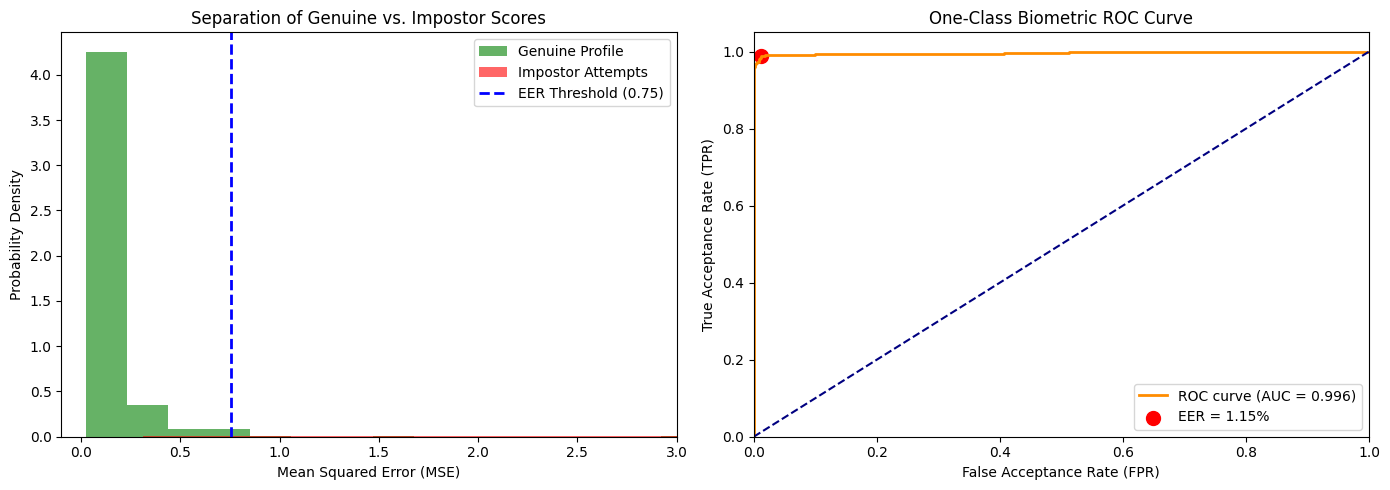

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(genuine_scores, bins=20, alpha=0.6, label='Genuine Profile', color='g', density=True)
axes[0].hist(impostor_scores, bins=50, alpha=0.6, label='Impostor Attempts', color='r', density=True)
axes[0].axvline(optimal_threshold, color='blue', linestyle='--', lw=2, label=f'EER Threshold ({optimal_threshold:.2f})')
axes[0].set_xlim(-0.1, 3.0)
axes[0].set_title('Separation of Genuine vs. Impostor Scores')
axes[0].set_xlabel('Mean Squared Error (MSE)')
axes[0].set_ylabel('Probability Density')
axes[0].legend()

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].scatter(eer, 1 - eer, color='red', marker='o', s=100, label=f'EER = {eer*100:.2f}%')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Acceptance Rate (FPR)')
axes[1].set_ylabel('True Acceptance Rate (TPR)')
axes[1].set_title('One-Class Biometric ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
def live_authentication_gate(user_id, repetition_number=1, session_index=1):

    sample_row = df[
        (df['subject'] == user_id) &
        (df['sessionIndex'] == session_index) &
        (df['rep'] == repetition_number)
    ]

    if sample_row.empty:
        print(f"🚨 Error: User '{user_id}' with Session #{session_index}, Repetition #{repetition_number} not found.")
        return

    raw_pattern = sample_row[feature_cols].values

    scaled_pattern = scaler.transform(raw_pattern)

    z_mean_val, _, _ = encoder.predict(scaled_pattern, verbose=0)
    reconstruction = decoder.predict(z_mean_val, verbose=0)

    single_mse = np.mean(np.square(scaled_pattern - reconstruction))

    print("=" * 55)
    print(f"            BIOMETRIC GATEWAY VERIFICATION            ")
    print("=" * 55)
    print(f"Incoming Identity Claim:  {user_id}")
    print(f"Isolated Session Segment: Session #{session_index}")
    print(f"Isolated Attempt Index:   Repetition #{repetition_number}")
    print(f"Calculated Anomaly Score: {single_mse:.4f}")
    print(f"System Security Cutoff:   {optimal_threshold:.4f}")
    print("-" * 55)

    if single_mse <= optimal_threshold:
        print(f"🟢 [ACCESS GRANTED]: Identity verified successfully.")
        print(f"   The VAE perfectly reconstructed the typing signature.")
    else:
        print(f"🔴 [ACCESS DENIED]: Intruder anomaly detected!")
        print(f"   Rhythm profile deviates too far from the target template.")
    print("=" * 55 + "\n")


print("\n--- SIMULATING LIVE VERIFICATION (SINGULAR RUN MODE) ---")

live_authentication_gate(user_id=target_user, repetition_number=1, session_index=1)

live_authentication_gate(user_id="s050", repetition_number=20, session_index=4)


--- SIMULATING LIVE VERIFICATION (SINGULAR RUN MODE) ---
            BIOMETRIC GATEWAY VERIFICATION            
Incoming Identity Claim:  s010
Isolated Session Segment: Session #1
Isolated Attempt Index:   Repetition #1
Calculated Anomaly Score: 0.1146
System Security Cutoff:   0.7540
-------------------------------------------------------
🟢 [ACCESS GRANTED]: Identity verified successfully.
   The VAE perfectly reconstructed the typing signature.

            BIOMETRIC GATEWAY VERIFICATION            
Incoming Identity Claim:  s050
Isolated Session Segment: Session #4
Isolated Attempt Index:   Repetition #20
Calculated Anomaly Score: 2.1316
System Security Cutoff:   0.7540
-------------------------------------------------------
🔴 [ACCESS DENIED]: Intruder anomaly detected!
   Rhythm profile deviates too far from the target template.

